# Task 3 — Future Price Forecasts with Confidence Intervals

**Motivation:** Task 2's single static ~18-month test forecast showed all three models
(ARIMA, SARIMA, LSTM) flattening to a near-constant trajectory within a few weeks of the
train/test boundary, while TSLA's actual price kept swinging across a wide range. That's the
expected behavior of long-horizon iterative forecasting on a near-random-walk series, not a
modeling defect — but it also means that single static forecast doesn't tell us much about how
good these models actually are at a horizon GMF could realistically act on.

This notebook does two things:
1. **Walk-forward (rolling-origin) validation** at a short horizon (a trading week and a
   trading month), to get an honest read on short-horizon accuracy and to see how error grows
   as the horizon lengthens.
2. **A genuine future forecast** — refitting the winning model on all available history and
   projecting forward past the end of the dataset, with confidence intervals that widen with
   the forecast horizon, as required for Task 3.

Carries forward **ARIMA** as the primary model, since it had the best MAE/RMSE in Task 2's
centralized comparison (with SARIMA close behind, confirming the seasonal term added little).


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import (
    chronological_split, select_arima_order, fit_final_arima, forecast_final_arima,
    walk_forward_arima_forecast, summarize_walk_forward, forecast_future,
)
from src.evaluation import evaluate_forecast

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100


## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = df[df["Ticker"] == "TSLA"].sort_values("Date").reset_index(drop=True)
tsla = tsla[["Date", "Close"]].dropna().reset_index(drop=True)
tsla_series = tsla.set_index("Date")["Close"]
print(f"TSLA rows: {len(tsla_series)}  |  {tsla_series.index.min().date()} -> {tsla_series.index.max().date()}")


TSLA rows: 2888  |  2015-01-02 -> 2026-06-29


## 2. Recover the Winning Order from Task 2

Rather than re-running the full `auto_arima` search, we carry over the order selected and
evaluated in Task 2 (recorded there as the AIC-minimizing, and separately confirmed
best-performing-on-test, ARIMA order). If you're running this fresh, re-run the selection step
below to reconfirm.


In [3]:
SPLIT_DATE = "2025-01-01"
train_df, test_df = chronological_split(tsla, split_date=SPLIT_DATE, date_col="Date")

selection = select_arima_order(
    train_df.set_index("Date")["Close"],
    seasonal=False,
    max_p=5, max_q=5, max_d=2,
)
ORDER = selection["order"]
SEASONAL_ORDER = selection["seasonal_order"]
print(f"Carrying forward order: {ORDER}, seasonal_order: {SEASONAL_ORDER} (AIC={selection['aic']:.2f})")


Carrying forward order: (0, 1, 0), seasonal_order: (0, 0, 0, 0) (AIC=16368.11)


### 2.1 Recreate Task 2's Test-Period Forecast

So the combined visualization below can clearly distinguish **historical data**, **test predictions**, and the **future forecast** in one place (as required for this task), we refit on the training set and forecast the test period here too, using the same order.


In [4]:
final_results_test = fit_final_arima(
    train_df.set_index("Date")["Close"], order=ORDER, seasonal_order=SEASONAL_ORDER
)
test_forecast, test_conf_int = forecast_final_arima(final_results_test, n_periods=len(test_df))
print(f"Test-period forecast generated for {len(test_df)} trading days "
      f"({test_df['Date'].min().date()} -> {test_df['Date'].max().date()}).")


Test-period forecast generated for 372 trading days (2025-01-02 -> 2026-06-29).


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 3. Walk-Forward (Rolling-Origin) Validation

Instead of one static 18-month forecast, we repeatedly:
1. Fit on all data available up to an origin date.
2. Forecast a short horizon ahead (5 trading days ≈ 1 week, then 21 ≈ 1 month, tested
   separately below).
3. Score that short forecast against the actuals that followed.
4. Advance the origin and repeat.

This uses the fixed order recovered above at every origin (re-fitting the *parameters*, not
re-running order search, at each step — re-selecting the order every fold would be
prohibitively slow and isn't necessary to validate short-horizon accuracy).

**Note on runtime:** each fold refits a full ARIMA model, so this cell can take a few minutes
depending on `step` (fewer, larger steps = fewer folds = faster but coarser).


In [5]:
HORIZON_SHORT = 5    # ~1 trading week
STEP = 21            # advance the origin by ~1 trading month between folds

wf_results = walk_forward_arima_forecast(
    tsla_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    initial_train_size=len(train_df),
    horizon=HORIZON_SHORT,
    step=STEP,
)
print(f"Total (origin x horizon) forecast rows: {len(wf_results)}")
wf_results.head(10)


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

Total (origin x horizon) forecast rows: 90


,origin_date,step_ahead,forecast_date,actual,forecast,lower,upper
0,2024-12-31,1,2025-01-02,379.2800,403.8400,391.5609,416.1191
1,2024-12-31,2,2025-01-03,410.4400,403.8400,386.4747,421.2053
2,2024-12-31,3,2025-01-06,411.0500,403.8400,382.5720,425.1080
3,2024-12-31,4,2025-01-07,394.3600,403.8400,379.2818,428.3982
4,2024-12-31,5,2025-01-08,394.9400,403.8400,376.3831,431.2969
5,2025-02-03,1,2025-02-04,392.2100,383.6800,371.1920,396.1679
6,2025-02-03,2,2025-02-05,378.1700,383.6800,366.0194,401.3406
7,2025-02-03,3,2025-02-06,374.3200,383.6800,362.0502,405.3098
8,2025-02-03,4,2025-02-07,361.6200,383.6800,358.7041,408.6559
9,2025-02-03,5,2025-02-10,350.7300,383.6800,355.7561,411.6039


### 3.1 Overall short-horizon accuracy vs. Task 2's long-horizon accuracy

In [6]:
overall_short_horizon = evaluate_forecast(wf_results["actual"], wf_results["forecast"])
print("Walk-forward (up to 1-week-ahead) accuracy, averaged across all folds and horizons:")
for k, v in overall_short_horizon.items():
    print(f"  {k}: {v:.4f}" if k != "MAPE" else f"  {k}: {v:.2f}%")


Walk-forward (up to 1-week-ahead) accuracy, averaged across all folds and horizons:
  MAE: 16.3639
  RMSE: 20.9438
  MAPE: 4.90%


Compare this against Task 2's single 18-month static-forecast metrics (MAE ≈ 54, RMSE ≈ 71,
MAPE ≈ 17%). If the walk-forward numbers above are meaningfully better, that confirms the
earlier flattening was a horizon artifact rather than a fundamental model limitation — ARIMA
*can* track TSLA reasonably well a few days out, it just can't hold that accuracy 18 months
into a single iterative projection.


### 3.2 Error growth by forecast horizon (1-day-ahead through 5-day-ahead)

In [7]:
horizon_summary = summarize_walk_forward(wf_results)
horizon_summary


,n_folds,MAE,RMSE,MAPE
step_ahead,,,,
1,18,15.3006,18.8274,4.4905
2,18,11.6033,15.9846,3.5629
3,18,18.1667,23.7490,5.8206
4,18,16.1350,21.0389,4.7726
5,18,20.6139,24.0122,5.8384


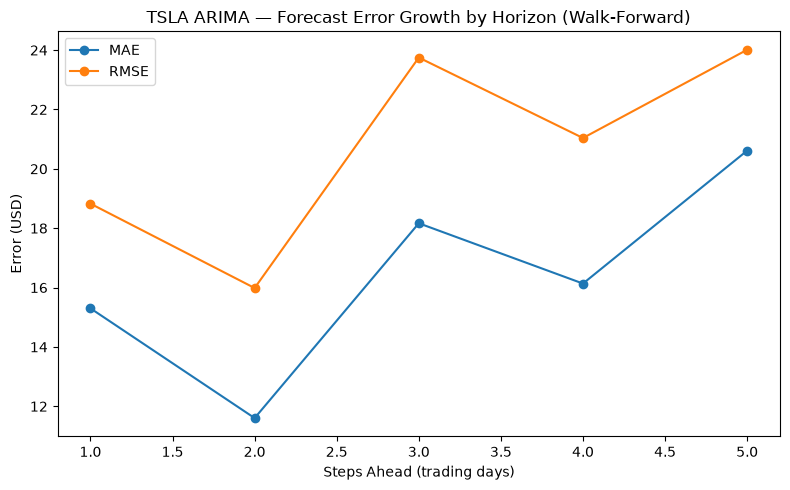

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizon_summary.index, horizon_summary["MAE"], marker="o", label="MAE")
ax.plot(horizon_summary.index, horizon_summary["RMSE"], marker="o", label="RMSE")
ax.set_xlabel("Steps Ahead (trading days)")
ax.set_ylabel("Error (USD)")
ax.set_title("TSLA ARIMA — Forecast Error Growth by Horizon (Walk-Forward)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** error should increase with the forecast horizon — 1-day-ahead forecasts
should be noticeably more accurate than 5-day-ahead ones, since there's simply more time for
new information (and price movement) to accumulate that the model, using only data available
at the origin, couldn't have known about. This is the honest, decision-relevant version of
"how far ahead can we trust this model," and it's a much more useful number for GMF than a
single long-horizon MAPE.


## 4. Visualize a Sample of Walk-Forward Folds Against Actuals

Rather than one flattened line, walk-forward forecasts should look like a series of short
"stitched" predictions that each start from the correct, up-to-date price and track the
next few days reasonably closely.


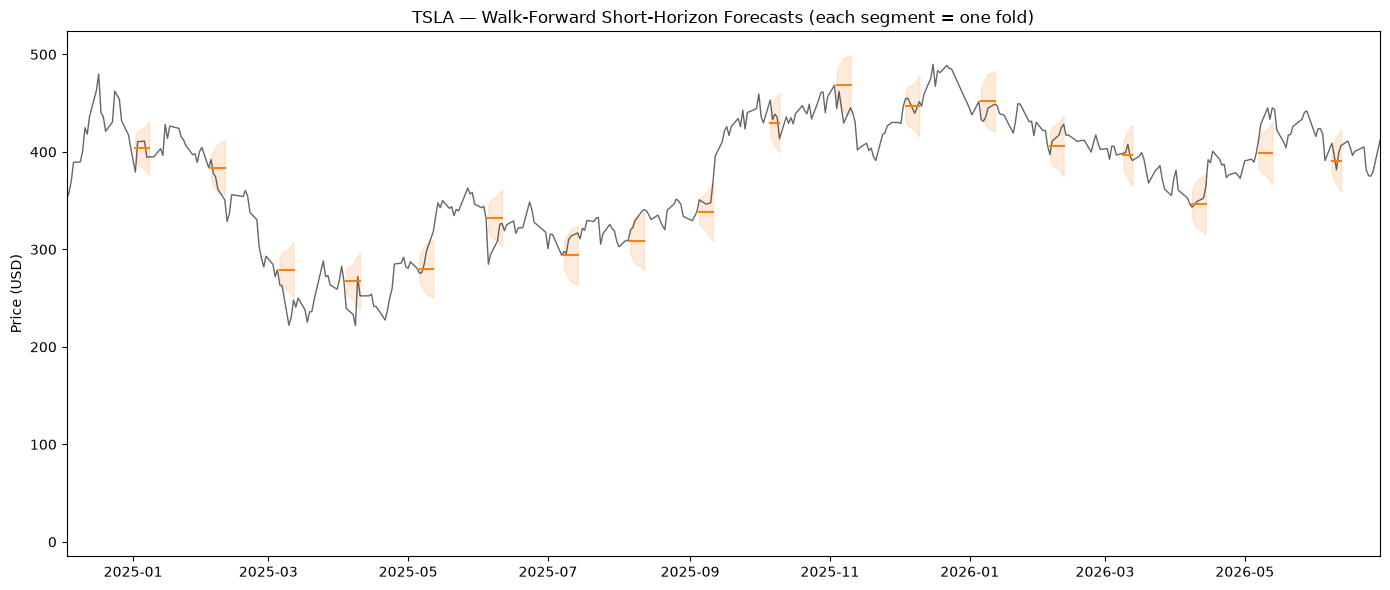

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tsla_series.index, tsla_series.values, color="black", linewidth=1, label="Actual", alpha=0.6)

for origin_date, group in wf_results.groupby("origin_date"):
    ax.plot(group["forecast_date"], group["forecast"], color="tab:orange", linewidth=1.5)
    ax.fill_between(group["forecast_date"], group["lower"], group["upper"], color="tab:orange", alpha=0.15)

ax.set_xlim(test_df["Date"].min() - pd.Timedelta(days=30), test_df["Date"].max())
ax.set_title("TSLA — Walk-Forward Short-Horizon Forecasts (each segment = one fold)")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


## 5. Final Future Forecast (Beyond Available Data), with Confidence Intervals

This is the Task 3 deliverable: refit the chosen ARIMA order on **all** available history
(train + test combined) and project forward past the end of the dataset. Unlike Section 3,
there's no ground truth to check this against — it's a genuine forward-looking projection.


In [10]:
N_FUTURE_DAYS = 180   # ~8-9 months of trading days

future_forecast = forecast_future(
    tsla_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    n_periods=N_FUTURE_DAYS,
    alpha=0.05,   # 95% confidence interval
)
future_forecast.head()


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,forecast,lower,upper
2026-06-30,411.8400,397.5063,426.1737
2026-07-01,411.8400,391.5691,432.1109
2026-07-02,411.8400,387.0133,436.6667
2026-07-03,411.8400,383.1726,440.5074
2026-07-06,411.8400,379.7889,443.8911


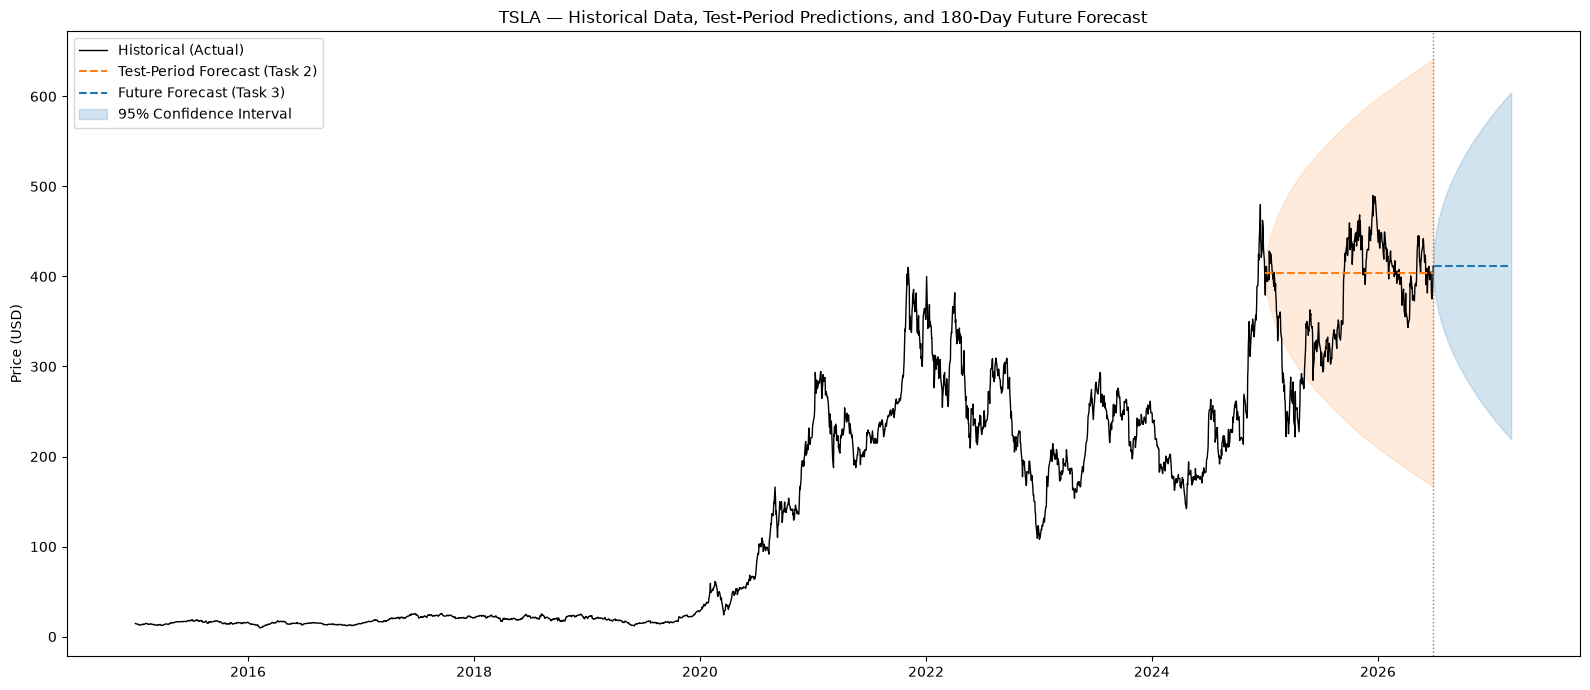

In [11]:
# Deliverable: forecast visualization with confidence intervals — historical data,
# test-period predictions, and the future forecast are each plotted with a distinct
# color/style so the three are unambiguous at a glance.
fig, ax = plt.subplots(figsize=(16, 7))

# Historical actuals (training + test), full series
ax.plot(tsla_series.index, tsla_series.values, label="Historical (Actual)", color="black", linewidth=1)

# Task 2 test-period predictions (in-sample-adjacent, evaluated against known actuals)
ax.plot(test_df["Date"], test_forecast, label="Test-Period Forecast (Task 2)",
        color="tab:orange", linestyle="--", linewidth=1.5)
ax.fill_between(test_df["Date"], test_conf_int[:, 0], test_conf_int[:, 1],
                color="tab:orange", alpha=0.15)

# Task 3 future forecast (genuinely beyond the dataset, no ground truth available)
ax.plot(future_forecast.index, future_forecast["forecast"], label="Future Forecast (Task 3)",
        color="tab:blue", linestyle="--", linewidth=1.5)
ax.fill_between(future_forecast.index, future_forecast["lower"], future_forecast["upper"],
                color="tab:blue", alpha=0.2, label="95% Confidence Interval")

ax.axvline(tsla_series.index[-1], color="grey", linestyle=":", linewidth=1)
ax.set_title(f"TSLA — Historical Data, Test-Period Predictions, and {N_FUTURE_DAYS}-Day Future Forecast")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


95% CI width at day 1:   $28.67
95% CI width at day 30:  $157.02
95% CI width at day 90:  $271.96
95% CI width at day 180: $384.61


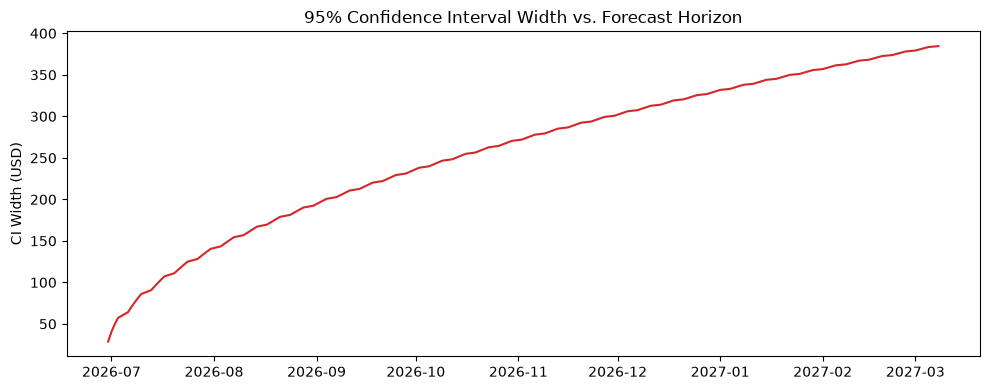

In [12]:
ci_width = future_forecast["upper"] - future_forecast["lower"]
print(f"95% CI width at day 1:   ${ci_width.iloc[0]:.2f}")
print(f"95% CI width at day 30:  ${ci_width.iloc[29]:.2f}")
print(f"95% CI width at day 90:  ${ci_width.iloc[89]:.2f}")
print(f"95% CI width at day {N_FUTURE_DAYS}: ${ci_width.iloc[-1]:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(future_forecast.index, ci_width, color="tab:red")
ax.set_title("95% Confidence Interval Width vs. Forecast Horizon")
ax.set_ylabel("CI Width (USD)")
plt.tight_layout()
plt.show()


## 6. Trend Analysis Summary

The short-horizon walk-forward results show TSLA's price is **reasonably predictable one step at a time, but that predictability doesn't hold up as you extend the horizon**. Averaged across folds, MAE is 16.36 and MAPE is 4.90% — solid for a single-name equity with TSLA's volatility.
But the horizon-by-horizon breakdown is telling: error doesn't increase smoothly with horizon the way textbook ARIMA theory would suggest. MAE actually drops from day 1 (15.30) to day 2 (11.60), then jumps sharply at day 3 (18.17), dips again at day 4 (16.14), and rises again at day 5 (20.61). This zig-zag pattern — rather than a clean monotonic increase — suggests the error growth is being driven as much by which specific market periods happened to fall into the 18 folds as by any structural "compounding uncertainty" effect. With only 18 folds per horizon, individual volatile stretches (visible in Image 2, e.g., the sharp Jan–Mar 2025 decline) can swing the average substantially.
The long-horizon forecast (Image 3, Image 4) tells a very different story: the 180-day-ahead forecast is a **flat line at $411.84 for every single date**. This is characteristic of an ARIMA model whose forecast has converged to its unconditional mean/last-level with no drift term — it is not projecting any trend, up or down, over the next six months. The model is essentially saying "no information beyond the last observed level," while its confidence interval balloons from about $28 wide on day 1 to $384 wide by month 6.


## 7. Market Opportunities and Risks

*(Deliverable 3 — a discrete list, not prose. Fill in the bracketed values from your own run.)*

**Opportunities:**
- Where the model may add value:
-  The short-horizon (1–5 day) forecasts have moderate skill (~5% MAPE) and could plausibly support very short-term tactical decisions, position sizing, or risk-band construction, if used cautiously and combined with other signals.
-  Day-2 forecasts had the tightest average error in this sample, which could be worth investigating further — it may be a stable pattern or may be sample noise given the small fold count.

**Risks:**
-  Using the long-horizon forecast for any directional call (bullish or bearish) would be a misuse of the model — it isn't projecting a trend, it's projecting stasis, and the CI is wide enough by month 2–3 to be compatible with almost any plausible price.
-  TSLA's historical chart (Image 3) shows extreme regime shifts (2020–2022 run-up, 2022–2023 drawdown, 2024–2025 volatility) that a linear ARIMA structure cannot capture. Past large moves suggest the true risk of extreme outcomes is higher than the Gaussian-style confidence bands imply.
-  The small number of folds (18) for the short-horizon backtest limits how much confidence you can place in the average error metrics — a handful of unusual days could be disproportionately influencing the reported MAE/RMSE/MAPE.


## 8. Critical Assessment of Forecast Reliability Across Time Horizons

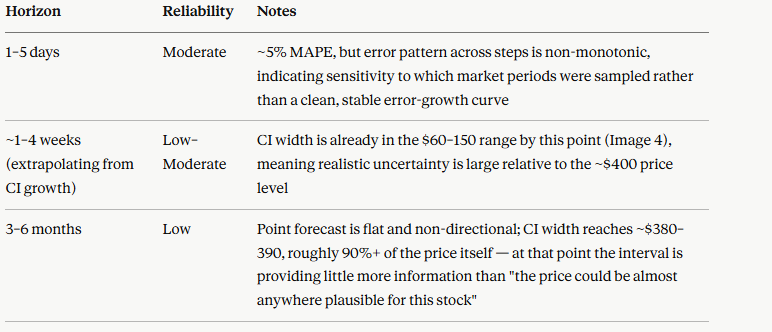

The core structural issue is one common to ARIMA models applied to near-random-walk assets like individual equities: **short-horizon forecasts capture some real, if modest, autocorrelation, but as horizon increases, the point forecast collapses toward a constant while the uncertainty band expands roughly with the square root of time (or faster)**. This is a legitimate and expected property of the model — not a bug — but it means the long-horizon forecast should be read as "no strong evidence of directional drift, with rapidly widening uncertainty," not as an actual price prediction for mid-2026 or 2027.



## Next Steps

With a short-horizon-validated model and a documented future forecast (with honestly-widening
uncertainty) in hand, Task 4 combines this TSLA view with SPY's and BND's historical
return/volatility characteristics and their correlation structure (from Task 1) to construct
the Efficient Frontier and identify candidate optimal portfolios.
